# calculate mean values of npz files from different recorders to test 

Data consists of 200 randomly chosen audiofiles from the recorders 6229 and 6230. 100 from each recorder. Used to calculate what the mean values of data in each recorder.

In [56]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

ROOT = Path(".").resolve().parent
print(ROOT)

/Users/johan/uni/bachelor/Detecting-Narwhals


In [64]:
npz_root = Path(ROOT / "output/mixedDataset/randomFiles/normal/npz")
files = list(npz_root.glob("*.npz"))
print(f"Number of .npz files: {len(files)}")


Number of .npz files: 199


In [65]:
# compute mean per bin across all files
means_per_bin = []
for f in files:
    data = np.load(f)
    spectrogram = data["feature"].squeeze()   # remove channel dim to get (n_bins, time_frames)
    mean_per_bin = spectrogram.mean(axis=1)   # average over time 
    means_per_bin.append(mean_per_bin)

means_per_bin = np.stack(means_per_bin)            # (n_files, freq_bins)
print(f"Stacked means per bin shape: {means_per_bin.shape} (files, bins)")

Stacked means per bin shape: (199, 128) (files, bins)


In [66]:
# group by recorder
recorders = {}
for f in files:
    recorder_id = f.stem.split(".")[0]  # get prefix before first dot
    if recorder_id not in recorders:
        recorders[recorder_id] = []
    recorders[recorder_id].append(f)

for recorder_id, recorder_files in recorders.items():
    print(f"Recorder {recorder_id}: {len(recorder_files)} files")


Recorder 6230: 99 files
Recorder 6229: 100 files


In [67]:

# compute mean and std per bin for each recorder

recorder_means = {}
for recorder_id, recorder_files in recorders.items():
    means_per_bin_recorder = []
    for f in recorder_files:
        data = np.load(f)
        spectrogram = data["feature"].squeeze()   # remove channel dim to get (n_bins, time_frames)
        mean_per_bin = spectrogram.mean(axis=1)   # average over time 
        means_per_bin_recorder.append(mean_per_bin)
    means_per_bin_recorder = np.stack(means_per_bin_recorder)  # (n_files_recorder, freq_bins)
    mean_profile = means_per_bin_recorder.mean(axis=0)  # average across files of this recorder
    std_profile  = means_per_bin_recorder.std(axis=0)   # variation across files of this recorder
    recorder_means[recorder_id] = (mean_profile, std_profile)

print(recorder_means["6229"][0].shape)  # mean profile shape (freq_bins,)
print(recorder_means["6229"][1].shape)  # std profile shape (freq_bins,)



(128,)
(128,)


In [68]:
# print per bin for one recorder
print("average dB per bin for recorder 6229:")
bin_means = dict(enumerate(recorder_means["6229"][0]))
for i, mean in bin_means.items():
    print(f"Bin {i}: {mean:.2f} dB")

average dB per bin for recorder 6229:
Bin 0: -100.00 dB
Bin 1: 91.29 dB
Bin 2: 99.48 dB
Bin 3: -100.00 dB
Bin 4: 88.44 dB
Bin 5: 88.62 dB
Bin 6: 77.70 dB
Bin 7: 91.96 dB
Bin 8: -100.00 dB
Bin 9: 91.69 dB
Bin 10: 86.81 dB
Bin 11: 91.80 dB
Bin 12: 89.73 dB
Bin 13: 92.66 dB
Bin 14: 90.77 dB
Bin 15: 94.06 dB
Bin 16: 90.16 dB
Bin 17: 95.64 dB
Bin 18: 91.86 dB
Bin 19: 95.33 dB
Bin 20: 94.24 dB
Bin 21: 93.56 dB
Bin 22: 96.43 dB
Bin 23: 94.15 dB
Bin 24: 95.07 dB
Bin 25: 95.86 dB
Bin 26: 95.45 dB
Bin 27: 95.66 dB
Bin 28: 95.82 dB
Bin 29: 95.21 dB
Bin 30: 95.88 dB
Bin 31: 95.00 dB
Bin 32: 95.56 dB
Bin 33: 95.58 dB
Bin 34: 95.48 dB
Bin 35: 95.39 dB
Bin 36: 95.29 dB
Bin 37: 95.14 dB
Bin 38: 94.93 dB
Bin 39: 94.68 dB
Bin 40: 94.41 dB
Bin 41: 94.69 dB
Bin 42: 94.25 dB
Bin 43: 93.89 dB
Bin 44: 93.67 dB
Bin 45: 94.13 dB
Bin 46: 93.53 dB
Bin 47: 93.12 dB
Bin 48: 93.83 dB
Bin 49: 92.66 dB
Bin 50: 93.70 dB
Bin 51: 92.74 dB
Bin 52: 93.33 dB
Bin 53: 93.33 dB
Bin 54: 93.39 dB
Bin 55: 93.59 dB
Bin 56: 94.05 

In [69]:
# Calculate mean values per frequency bin across all files
print(f"mean for recorder 6229: {np.mean(recorder_means['6229'][0]):.2f} dB")
print(f"mean for recorder 6230: {np.mean(recorder_means['6230'][0]):.2f} dB")
print(f"std_profile for recorder 6229: {np.mean(recorder_means['6229'][1]):.2f} dB")
print(f"std_profile for recorder 6230: {np.mean(recorder_means['6230'][1]):.2f} dB")

mean for recorder 6229: 84.12 dB
mean for recorder 6230: 76.65 dB
std_profile for recorder 6229: 3.35 dB
std_profile for recorder 6230: 4.39 dB


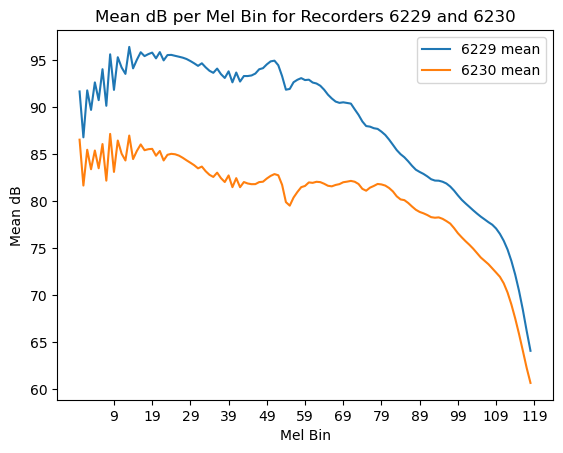

In [ ]:
plt.plot(recorder_means["6229"][0][9:], label="6229 mean")
plt.plot(recorder_means["6230"][0][9:], label="6230 mean")
plt.xlabel("Mel Bin")
plt.ylabel("Mean dB")
plt.title("Mean dB per Mel Bin for Recorders 6229 and 6230")

x_positions = np.arange(len(recorder_means["6229"][0][9:]))  # plotted positions (0..)
bin_numbers = x_positions + 9                                # actual bin numbers (9..127)

step = 10
plt.xticks(x_positions[::step], bin_numbers[::step])
plt.xlim(0, len(x_positions) - 1)

plt.legend()
plt.show()